# Japan Initial Velocity Model — Analysis & Visualization

This notebook analyzes the initial velocity model generated from **ETOPO** topography and **CRUST1.0** crustal structure,
blended with the **AK135** 1-D reference model at depth.

**Files:**
- `japan_model.h5` — Vp, Vs, xi, eta arrays `[nr, nt, np]`
- `japan_topo.h5` — ETOPO surface elevation `[nt, np]` in metres
- `input_params.yaml` — grid definition

In [1]:
import numpy as np
import h5py
import yaml
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

%matplotlib inline
plt.rcParams.update({"font.size": 12, "figure.dpi": 120})

## 1. Load Data

In [2]:
# --- Grid from YAML ---
with open("input_params.yaml", "r") as f:
    cfg = yaml.safe_load(f)

dom = cfg["domain"]
n_rtp = list(dom["n_rtp"])
depths = np.linspace(dom["min_max_dep"][0], dom["min_max_dep"][1], n_rtp[0])
lats   = np.linspace(dom["min_max_lat"][0], dom["min_max_lat"][1], n_rtp[1])
lons   = np.linspace(dom["min_max_lon"][0], dom["min_max_lon"][1], n_rtp[2])

print(f"Grid: nr={n_rtp[0]}, nt={n_rtp[1]}, np={n_rtp[2]}")
print(f"Depth: {depths[0]:.1f} – {depths[-1]:.1f} km")
print(f"Lat:   {lats[0]:.2f} – {lats[-1]:.2f}°")
print(f"Lon:   {lons[0]:.2f} – {lons[-1]:.2f}°")

Grid: nr=142, nt=111, np=131
Depth: -5.0 – 700.0 km
Lat:   24.00 – 46.00°
Lon:   122.00 – 148.00°


In [3]:
# --- Model ---
with h5py.File("japan_model.h5", "r") as f:
    vel_p = f["vel"][:]
    vel_s = f["vel_s"][:]
    print("Datasets:", list(f.keys()))

# --- Topography ---
with h5py.File("japan_topo.h5", "r") as f:
    topo_z = f["z"][:]  # metres

topo_km = topo_z / 1000.0

print(f"\nVp shape: {vel_p.shape}")
print(f"Vs shape: {vel_s.shape}")
print(f"Topo shape: {topo_km.shape}")

Datasets: ['eta', 'vel', 'vel_s', 'xi']

Vp shape: (142, 111, 131)
Vs shape: (142, 111, 131)
Topo shape: (111, 131)


## 2. Summary Statistics

In [4]:
print("=== Vp ===")
print(f"  Min:  {vel_p.min():.3f} km/s")
print(f"  Max:  {vel_p.max():.3f} km/s")
print(f"  Mean: {vel_p.mean():.3f} km/s")
print(f"  Std:  {vel_p.std():.3f} km/s")

print("\n=== Vs ===")
print(f"  Min:  {vel_s.min():.3f} km/s")
print(f"  Max:  {vel_s.max():.3f} km/s")
print(f"  Mean: {vel_s.mean():.3f} km/s")
print(f"  Std:  {vel_s.std():.3f} km/s")

print("\n=== Vp/Vs ratio (where Vs > 0) ===")
mask = vel_s > 0.1
ratio = np.where(mask, vel_p / vel_s, np.nan)
print(f"  Min:  {np.nanmin(ratio):.3f}")
print(f"  Max:  {np.nanmax(ratio):.3f}")
print(f"  Mean: {np.nanmean(ratio):.3f}")

print("\n=== Topography ===")
print(f"  Min elevation:  {topo_km.min():.2f} km (deepest ocean)")
print(f"  Max elevation:  {topo_km.max():.2f} km (highest land)")
print(f"  Mean elevation: {topo_km.mean():.2f} km")

=== Vp ===
  Min:  2.852 km/s
  Max:  10.891 km/s
  Mean: 8.913 km/s
  Std:  1.105 km/s

=== Vs ===
  Min:  1.036 km/s
  Max:  6.049 km/s
  Mean: 4.877 km/s
  Std:  0.613 km/s

=== Vp/Vs ratio (where Vs > 0) ===
  Min:  1.707
  Max:  2.753
  Mean: 1.830

=== Topography ===
  Min elevation:  -9.77 km (deepest ocean)
  Max elevation:  2.55 km (highest land)
  Mean elevation: -2.12 km


## 3. Topography Map

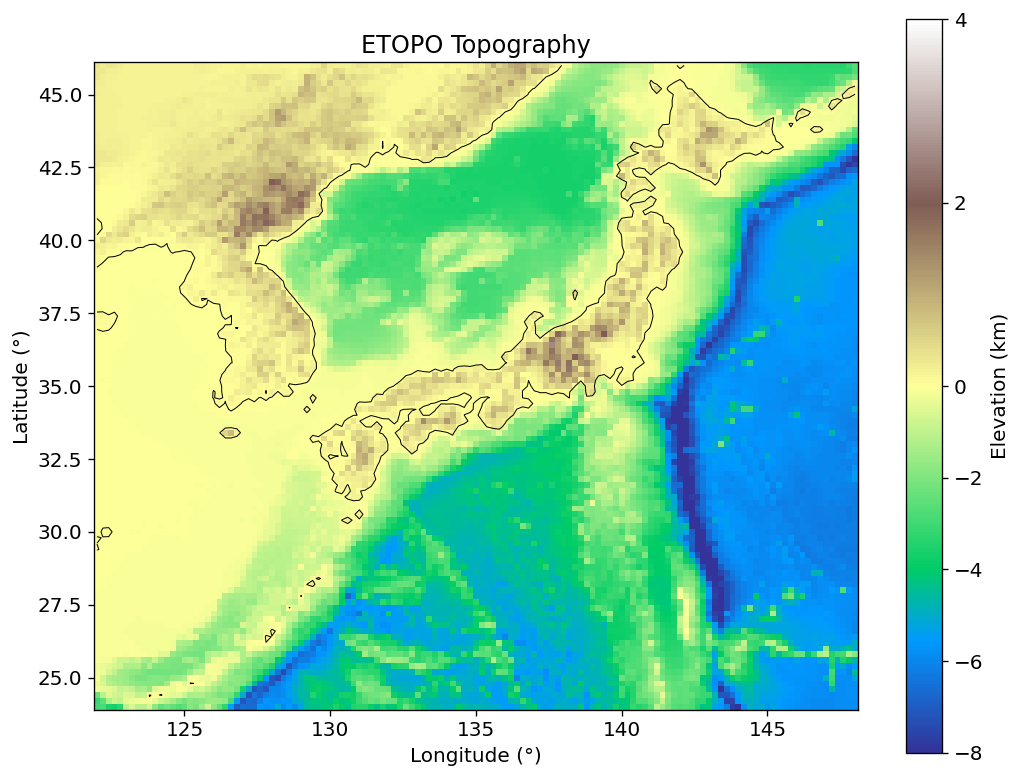

In [5]:
LON, LAT = np.meshgrid(lons, lats)

fig, ax = plt.subplots(figsize=(9, 8))
norm = TwoSlopeNorm(vmin=-8, vcenter=0, vmax=4)
im = ax.pcolormesh(LON, LAT, topo_km, cmap="terrain", norm=norm, shading="auto")
ax.contour(LON, LAT, topo_km, levels=[0], colors="k", linewidths=0.6)
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title("ETOPO Topography")
ax.set_aspect("equal")
fig.colorbar(im, ax=ax, label="Elevation (km)", shrink=0.8)
plt.tight_layout()
plt.show()

## 4. Horizontal Slices — Vp & Vs

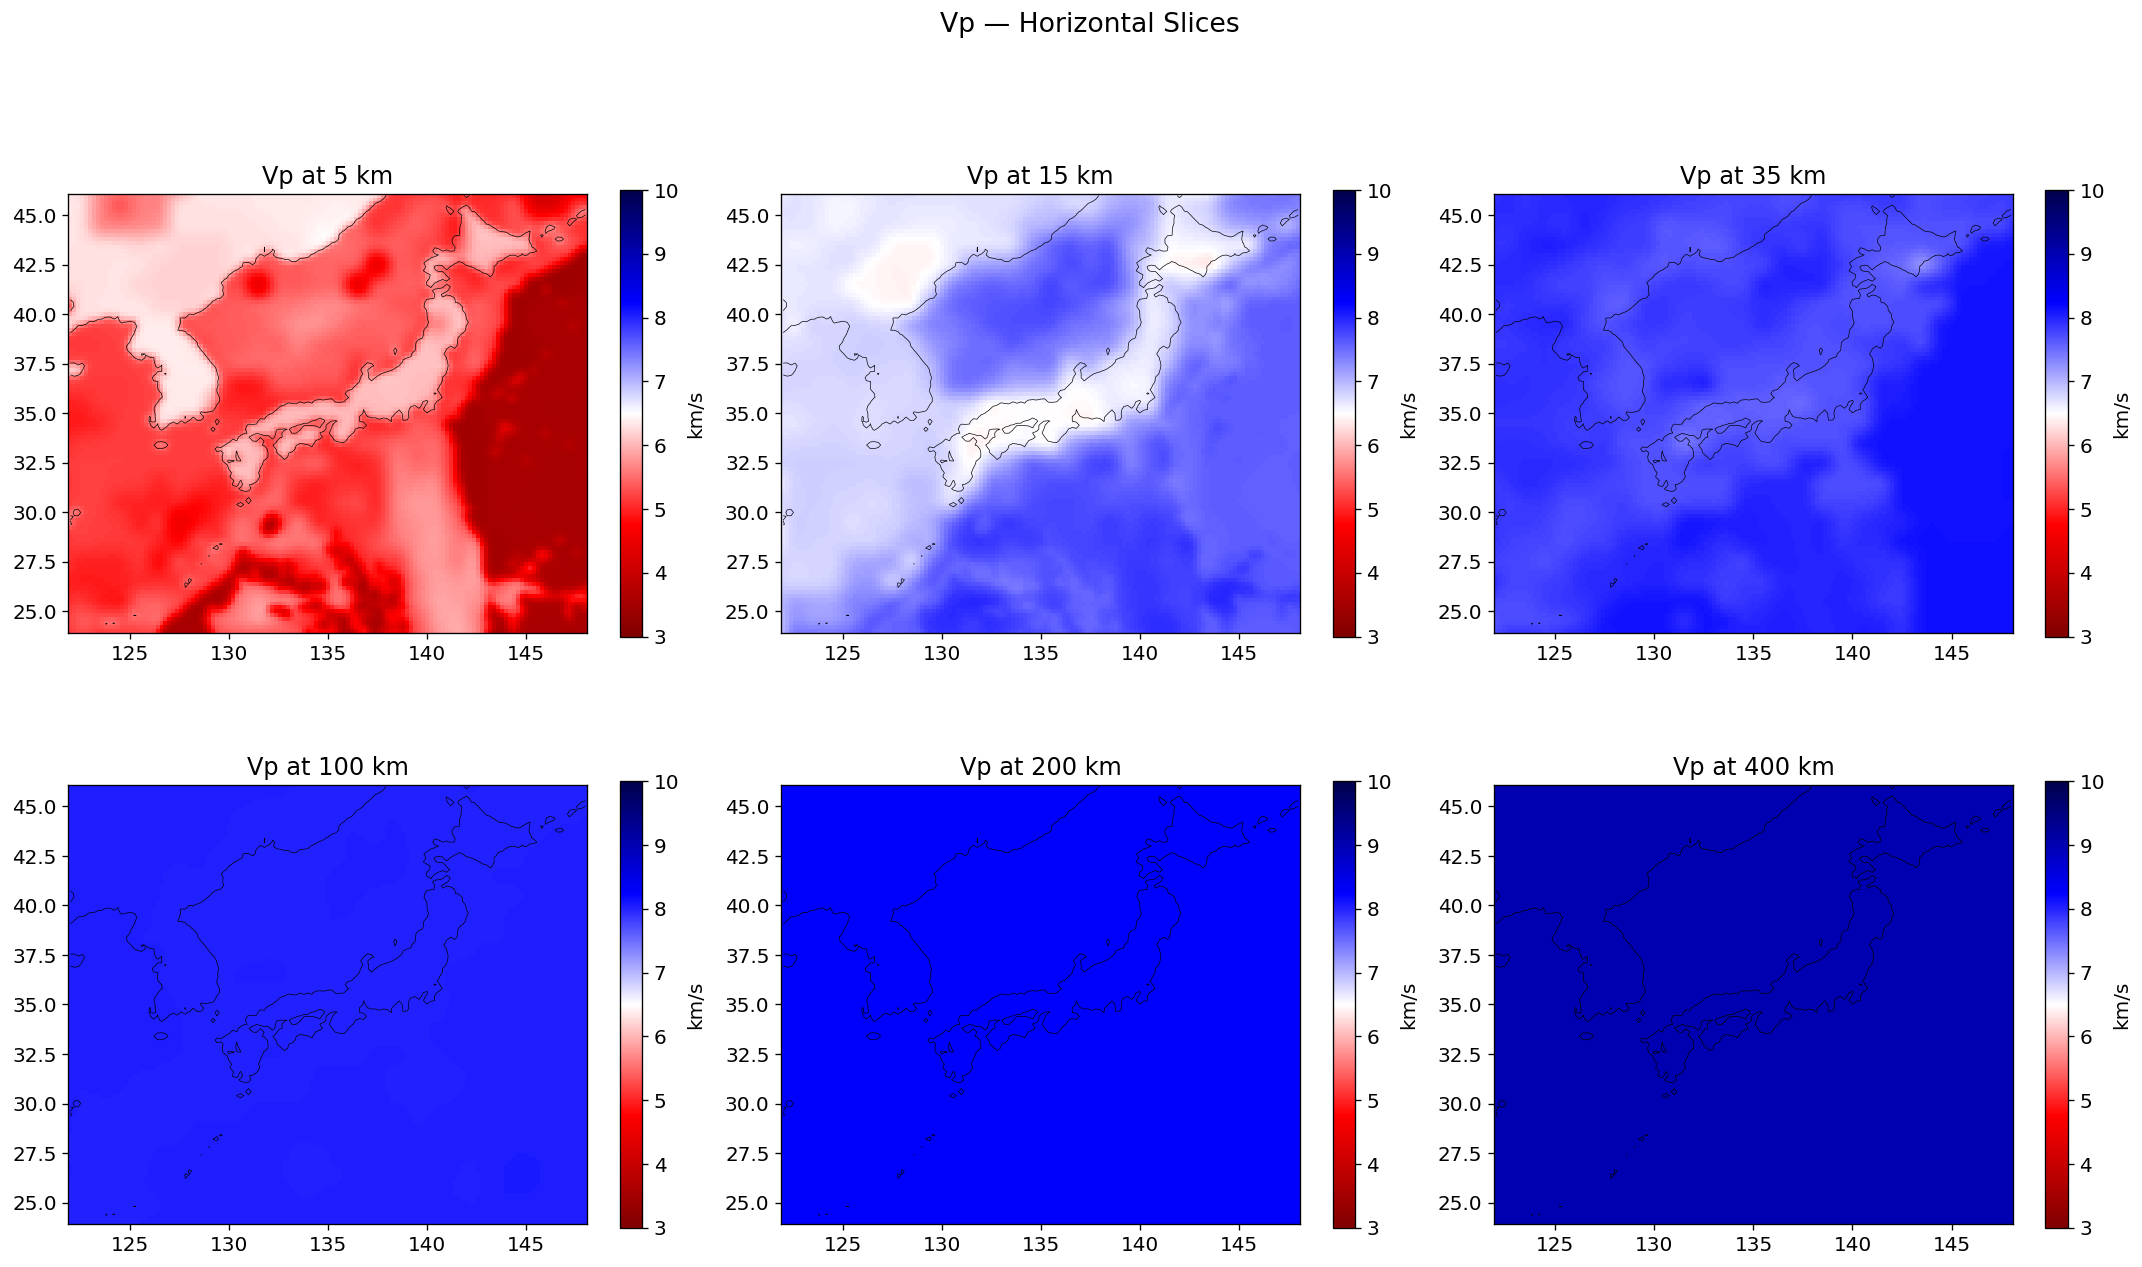

In [6]:
target_depths = [5, 15, 35, 100, 200, 400]  # km

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, td in zip(axes.flat, target_depths):
    idep = np.argmin(np.abs(depths - td))
    im = ax.pcolormesh(LON, LAT, vel_p[idep, :, :], cmap="seismic_r",
                       vmin=3.0, vmax=10.0, shading="auto")
    ax.contour(LON, LAT, topo_km, levels=[0], colors="k", linewidths=0.4)
    ax.set_title(f"Vp at {depths[idep]:.0f} km")
    ax.set_aspect("equal")
    fig.colorbar(im, ax=ax, shrink=0.7, label="km/s")
fig.suptitle("Vp — Horizontal Slices", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

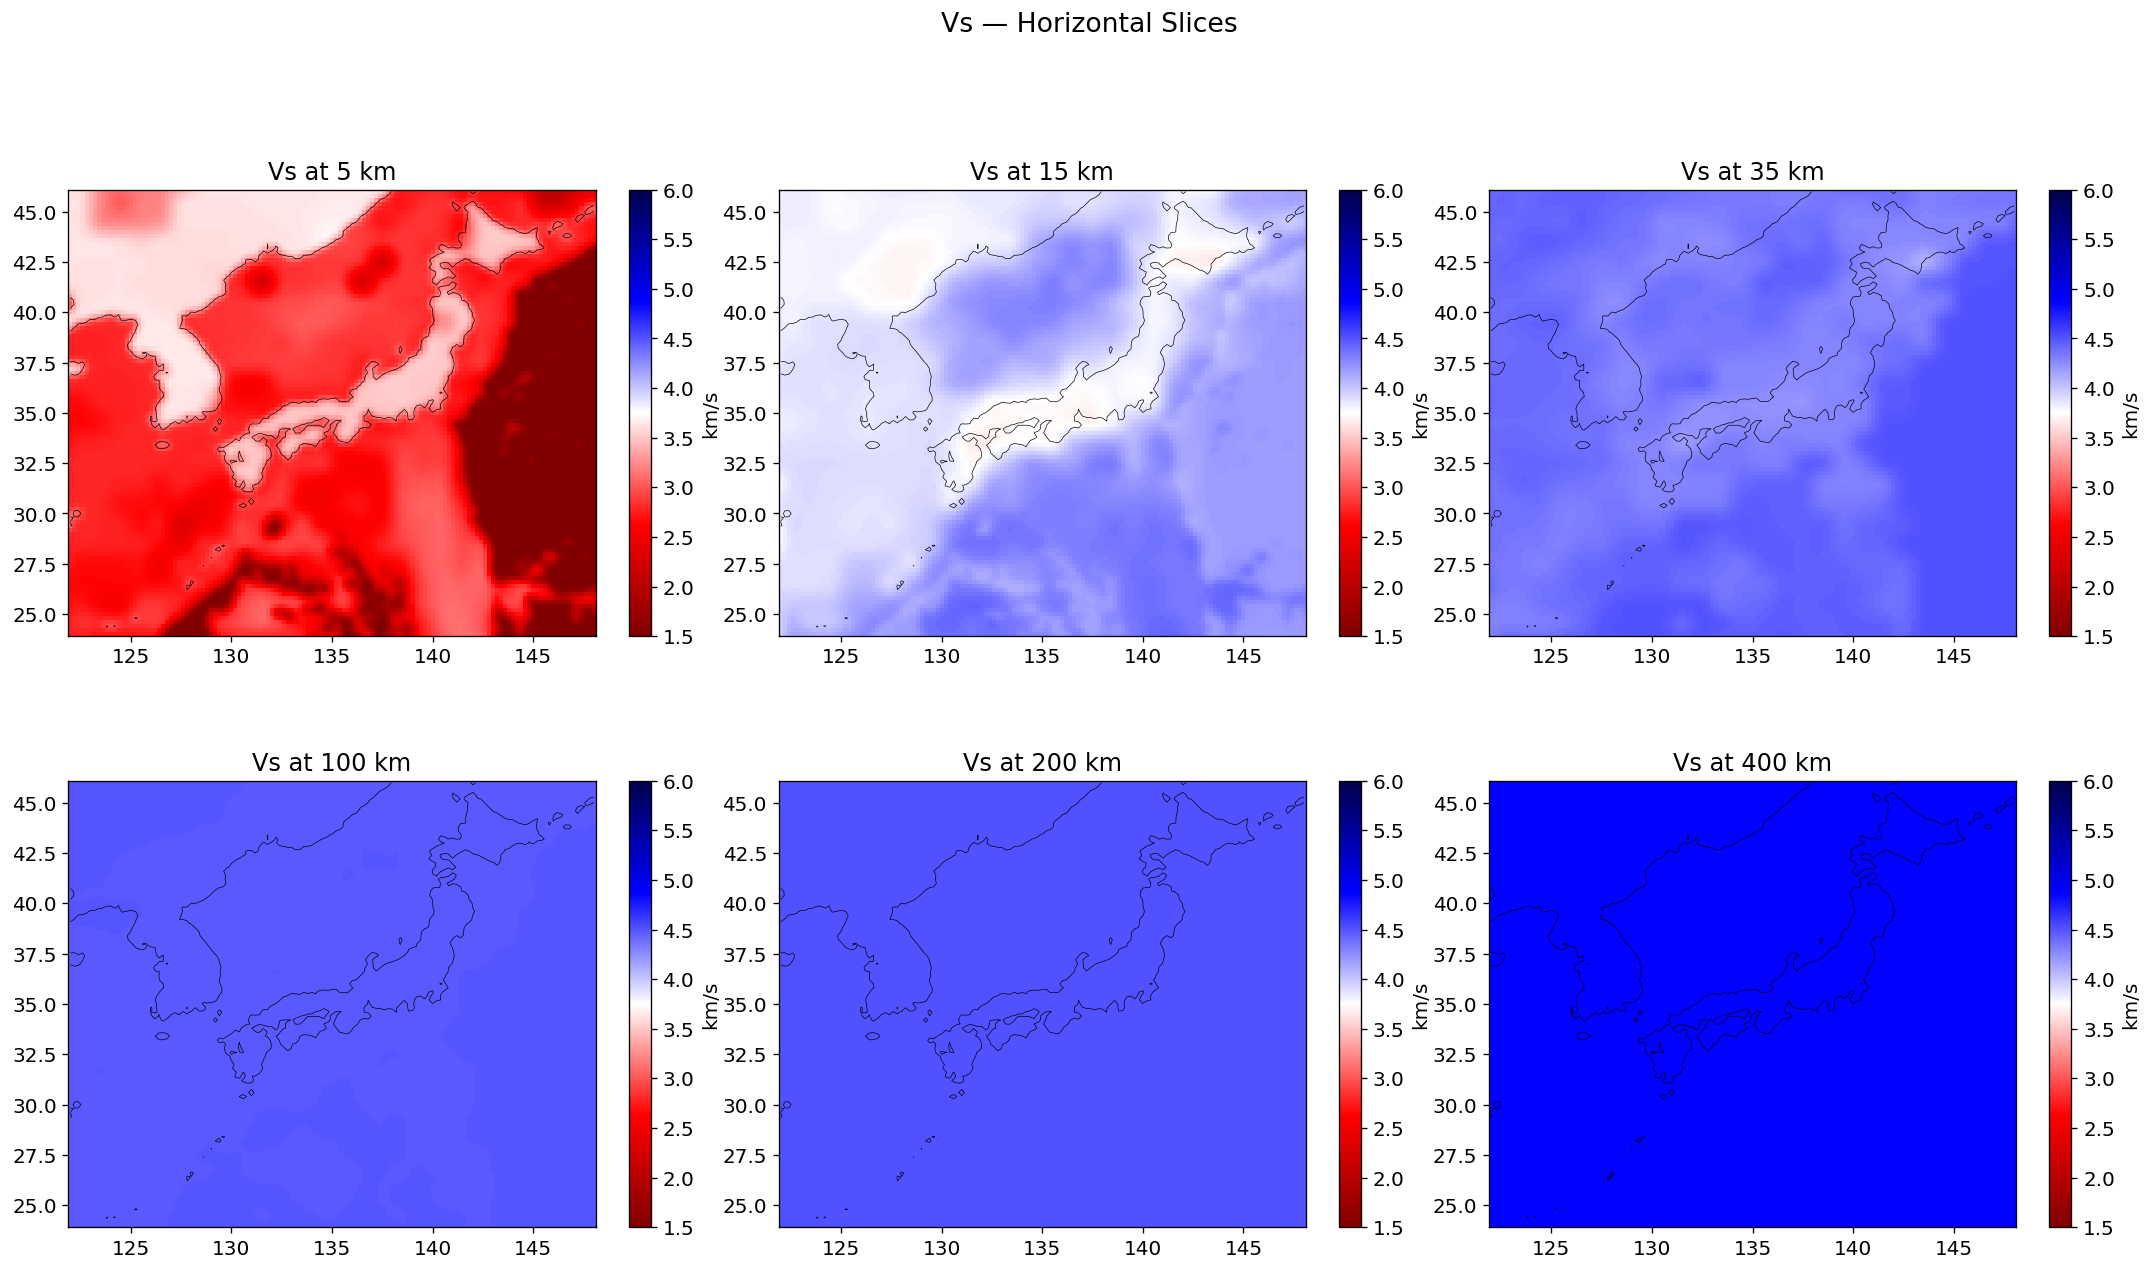

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, td in zip(axes.flat, target_depths):
    idep = np.argmin(np.abs(depths - td))
    im = ax.pcolormesh(LON, LAT, vel_s[idep, :, :], cmap="seismic_r",
                       vmin=1.5, vmax=6.0, shading="auto")
    ax.contour(LON, LAT, topo_km, levels=[0], colors="k", linewidths=0.4)
    ax.set_title(f"Vs at {depths[idep]:.0f} km")
    ax.set_aspect("equal")
    fig.colorbar(im, ax=ax, shrink=0.7, label="km/s")
fig.suptitle("Vs — Horizontal Slices", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 5. Vertical Cross-Sections

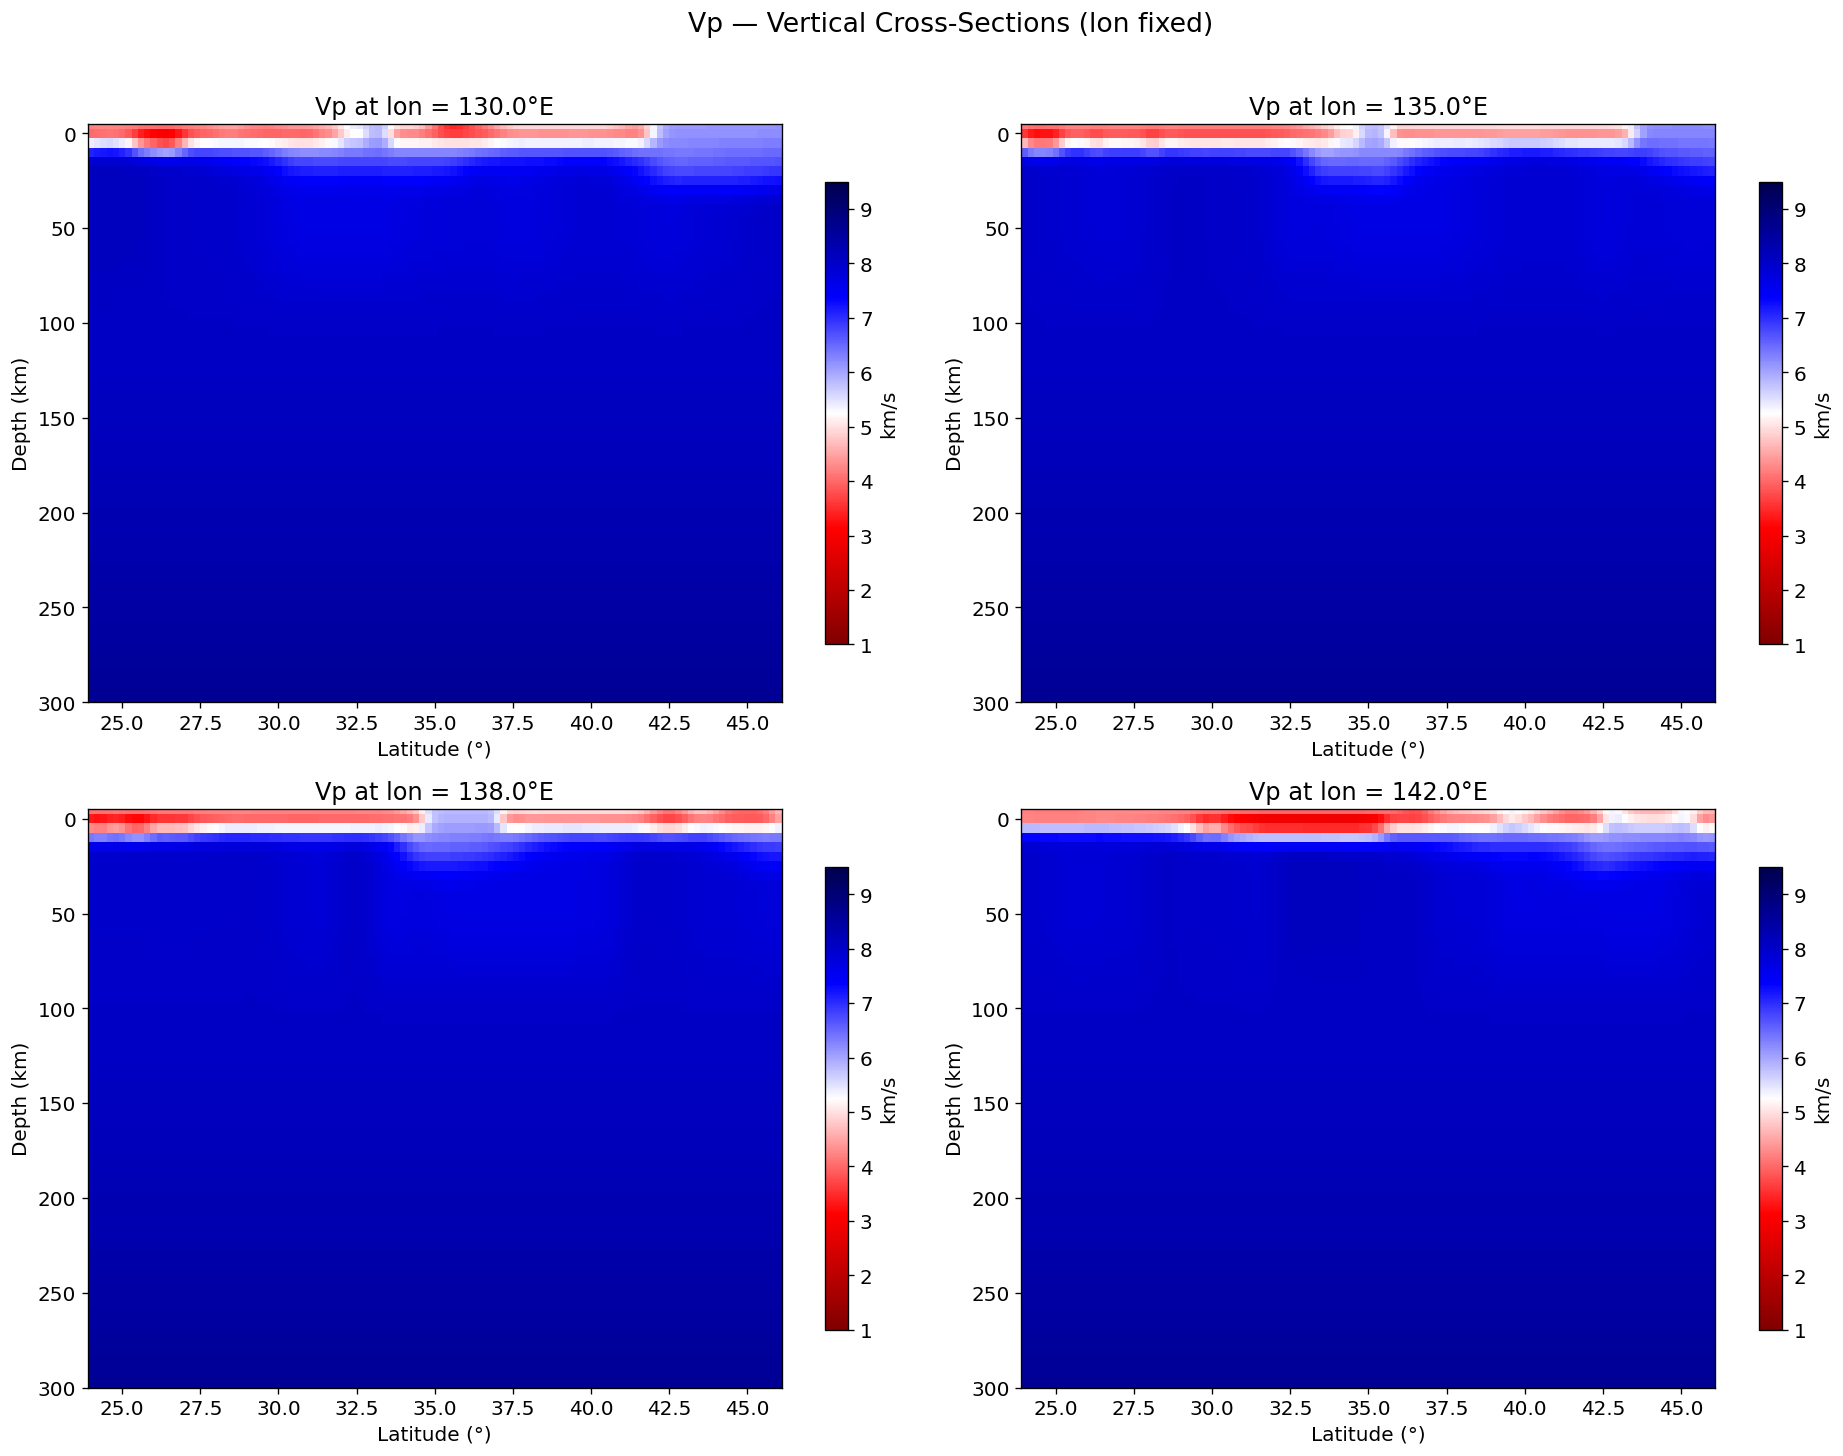

In [8]:
cross_lons = [130, 135, 138, 142]  # °E
max_plot_depth = 300  # km

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, tlon in zip(axes.flat, cross_lons):
    ilon = np.argmin(np.abs(lons - tlon))
    LATS, DEPS = np.meshgrid(lats, depths)
    im = ax.pcolormesh(LATS, DEPS, vel_p[:, :, ilon], cmap="seismic_r",
                       vmin=1.0, vmax=9.5, shading="auto")
    ax.set_ylim([max_plot_depth, depths[0]])
    ax.set_xlabel("Latitude (°)")
    ax.set_ylabel("Depth (km)")
    ax.set_title(f"Vp at lon = {lons[ilon]:.1f}°E")
    fig.colorbar(im, ax=ax, shrink=0.8, label="km/s")
fig.suptitle("Vp — Vertical Cross-Sections (lon fixed)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

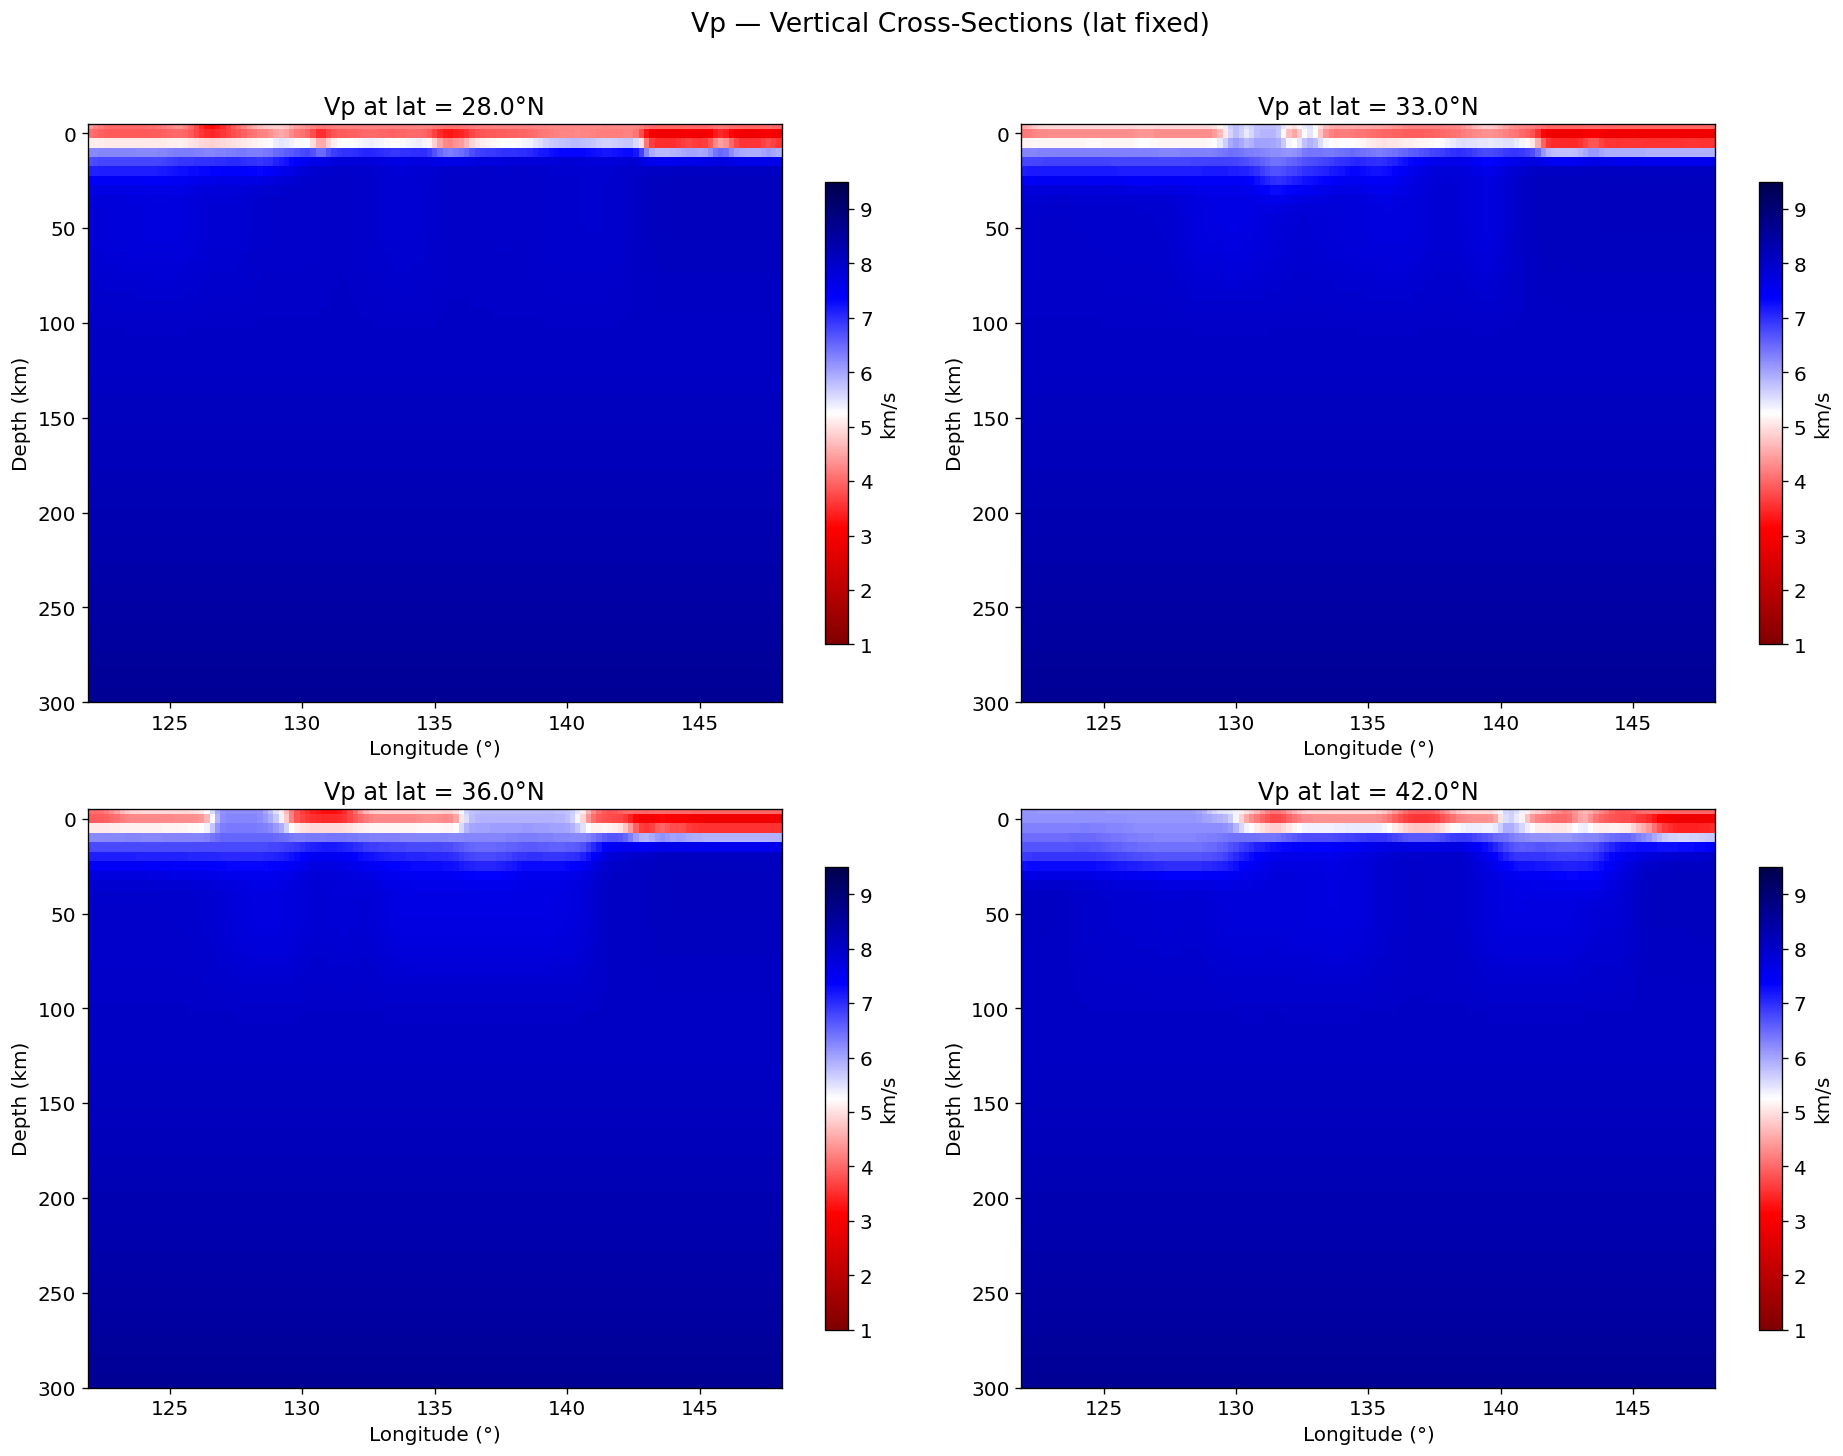

In [9]:
cross_lats = [28, 33, 36, 42]  # °N

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, tlat in zip(axes.flat, cross_lats):
    ilat = np.argmin(np.abs(lats - tlat))
    LONS, DEPS = np.meshgrid(lons, depths)
    im = ax.pcolormesh(LONS, DEPS, vel_p[:, ilat, :], cmap="seismic_r",
                       vmin=1.0, vmax=9.5, shading="auto")
    ax.set_ylim([max_plot_depth, depths[0]])
    ax.set_xlabel("Longitude (°)")
    ax.set_ylabel("Depth (km)")
    ax.set_title(f"Vp at lat = {lats[ilat]:.1f}°N")
    fig.colorbar(im, ax=ax, shrink=0.8, label="km/s")
fig.suptitle("Vp — Vertical Cross-Sections (lat fixed)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 6. Vp/Vs Ratio — Horizontal Slices

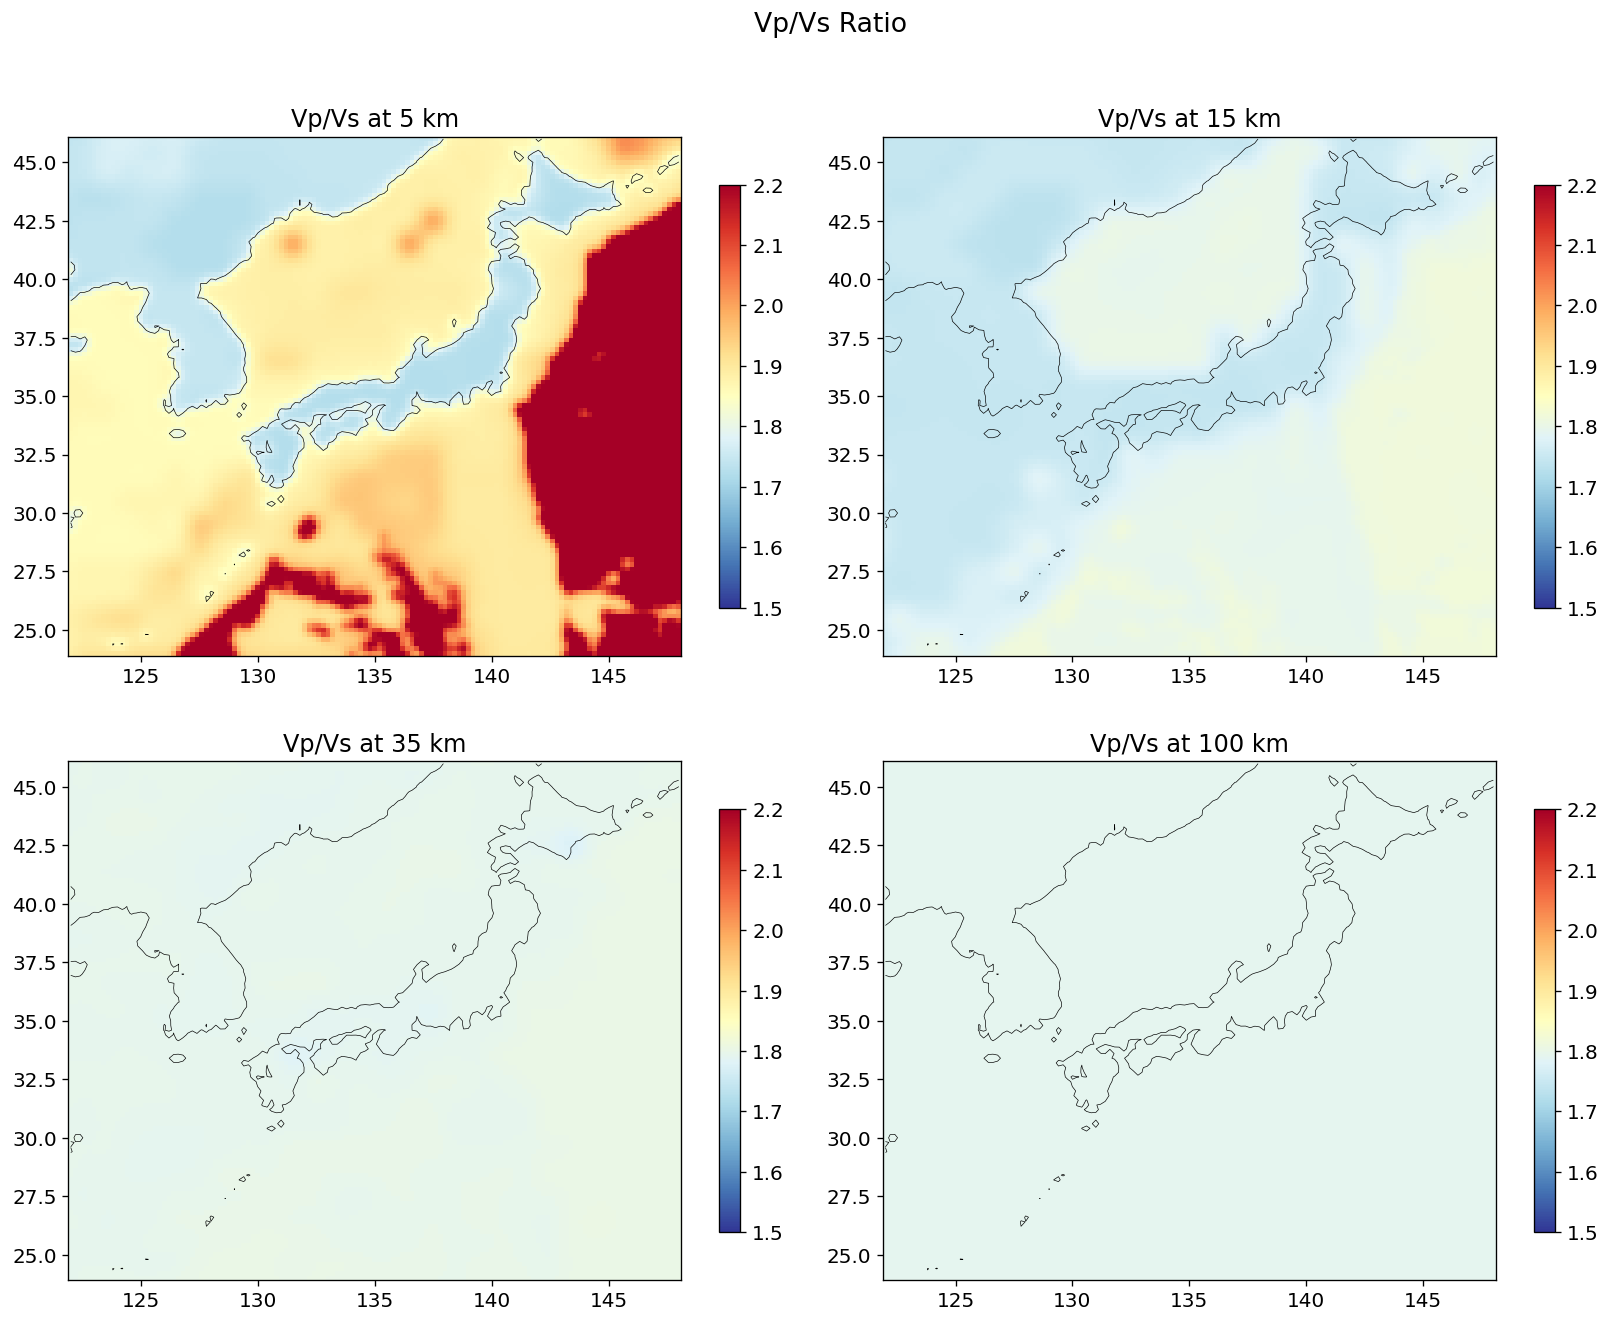

In [10]:
ratio_depths = [5, 15, 35, 100]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, td in zip(axes.flat, ratio_depths):
    idep = np.argmin(np.abs(depths - td))
    vp_slice = vel_p[idep, :, :]
    vs_slice = vel_s[idep, :, :]
    r = np.where(vs_slice > 0.1, vp_slice / vs_slice, np.nan)
    im = ax.pcolormesh(LON, LAT, r, cmap="RdYlBu_r",
                       vmin=1.5, vmax=2.2, shading="auto")
    ax.contour(LON, LAT, topo_km, levels=[0], colors="k", linewidths=0.4)
    ax.set_title(f"Vp/Vs at {depths[idep]:.0f} km")
    ax.set_aspect("equal")
    fig.colorbar(im, ax=ax, shrink=0.7)
fig.suptitle("Vp/Vs Ratio", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 7. Depth Profiles at Key Locations

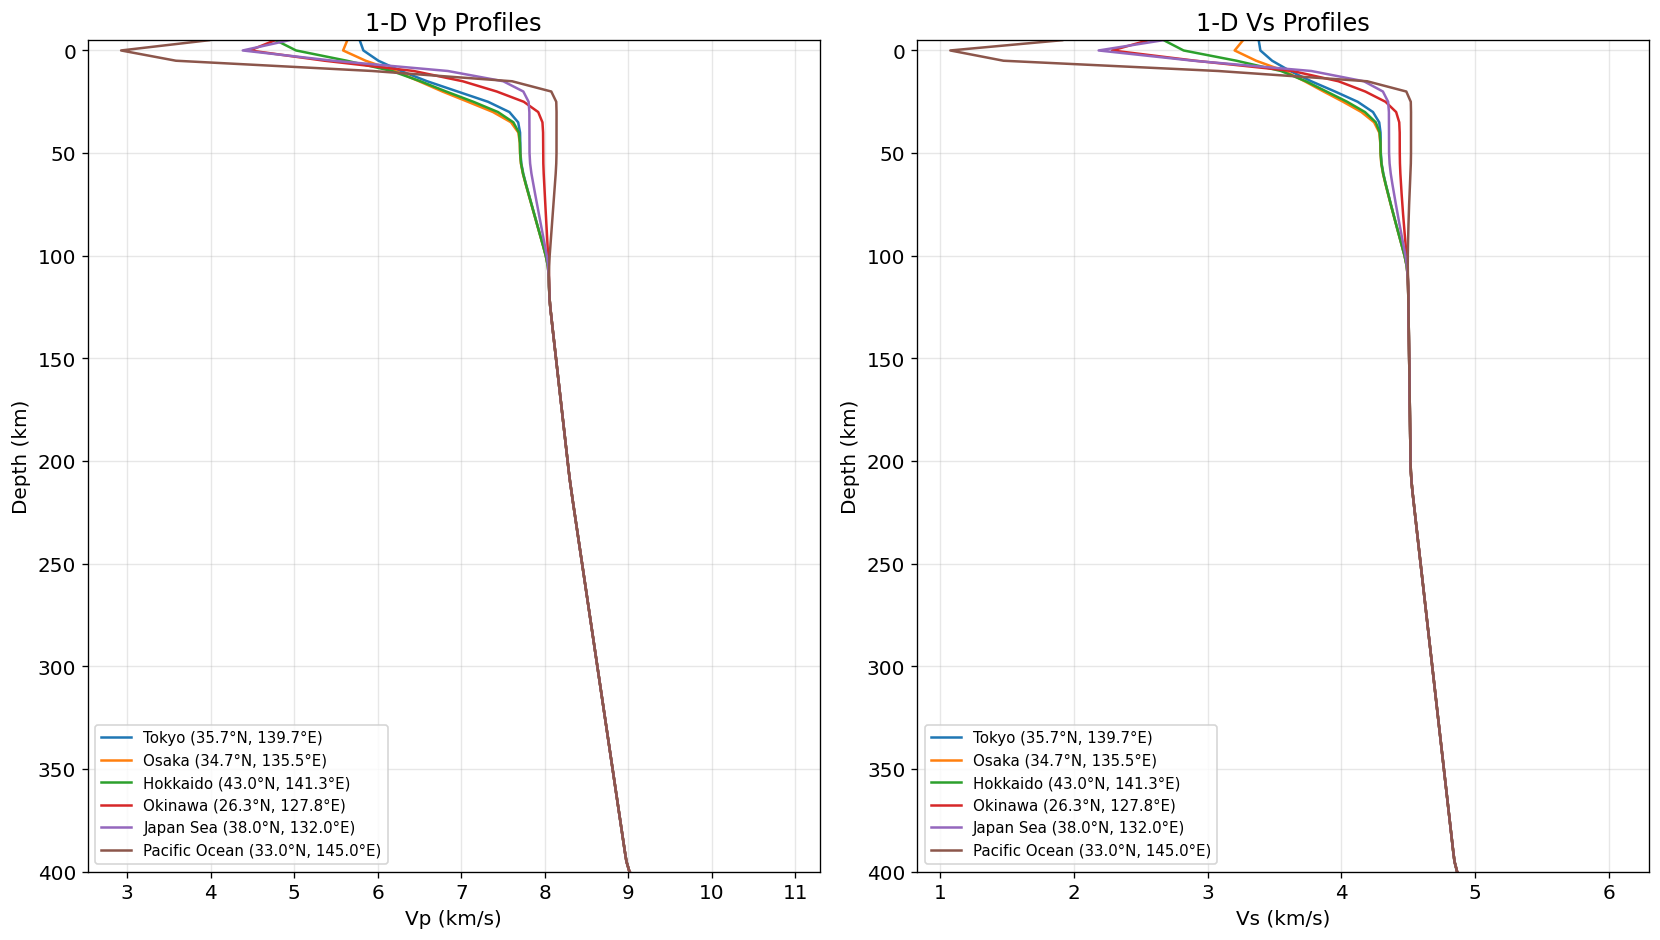

In [11]:
locations = {
    "Tokyo (35.7°N, 139.7°E)": (35.7, 139.7),
    "Osaka (34.7°N, 135.5°E)": (34.7, 135.5),
    "Hokkaido (43.0°N, 141.3°E)": (43.0, 141.3),
    "Okinawa (26.3°N, 127.8°E)": (26.3, 127.8),
    "Japan Sea (38.0°N, 132.0°E)": (38.0, 132.0),
    "Pacific Ocean (33.0°N, 145.0°E)": (33.0, 145.0),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for name, (lat, lon) in locations.items():
    ilat = np.argmin(np.abs(lats - lat))
    ilon = np.argmin(np.abs(lons - lon))
    axes[0].plot(vel_p[:, ilat, ilon], depths, label=name)
    axes[1].plot(vel_s[:, ilat, ilon], depths, label=name)

for ax, title in zip(axes, ["Vp (km/s)", "Vs (km/s)"]):
    ax.invert_yaxis()
    ax.set_ylim([400, depths[0]])
    ax.set_xlabel(title)
    ax.set_ylabel("Depth (km)")
    ax.set_title(f"1-D {title.split()[0]} Profiles")
    ax.legend(fontsize=9, loc="lower left")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Velocity Histograms

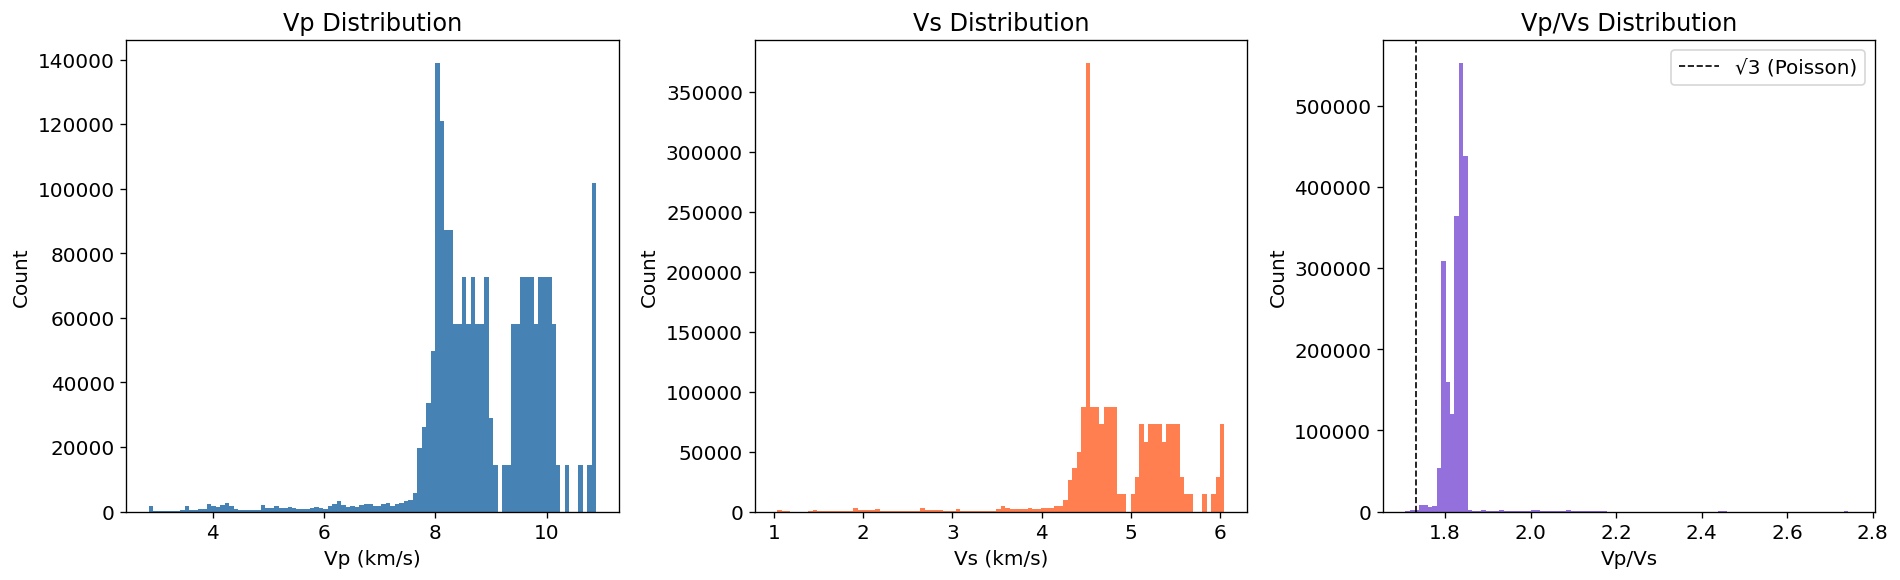

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Vp histogram
axes[0].hist(vel_p.ravel(), bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Vp (km/s)")
axes[0].set_ylabel("Count")
axes[0].set_title("Vp Distribution")

# Vs histogram
axes[1].hist(vel_s.ravel(), bins=100, color="coral", edgecolor="none")
axes[1].set_xlabel("Vs (km/s)")
axes[1].set_ylabel("Count")
axes[1].set_title("Vs Distribution")

# Vp/Vs histogram
valid_ratio = ratio[~np.isnan(ratio)].ravel()
axes[2].hist(valid_ratio, bins=100, color="mediumpurple", edgecolor="none")
axes[2].set_xlabel("Vp/Vs")
axes[2].set_ylabel("Count")
axes[2].set_title("Vp/Vs Distribution")
axes[2].axvline(1.732, color="k", ls="--", lw=1, label="√3 (Poisson)")
axes[2].legend()

plt.tight_layout()
plt.show()

## 9. Depth-Averaged Velocity Maps

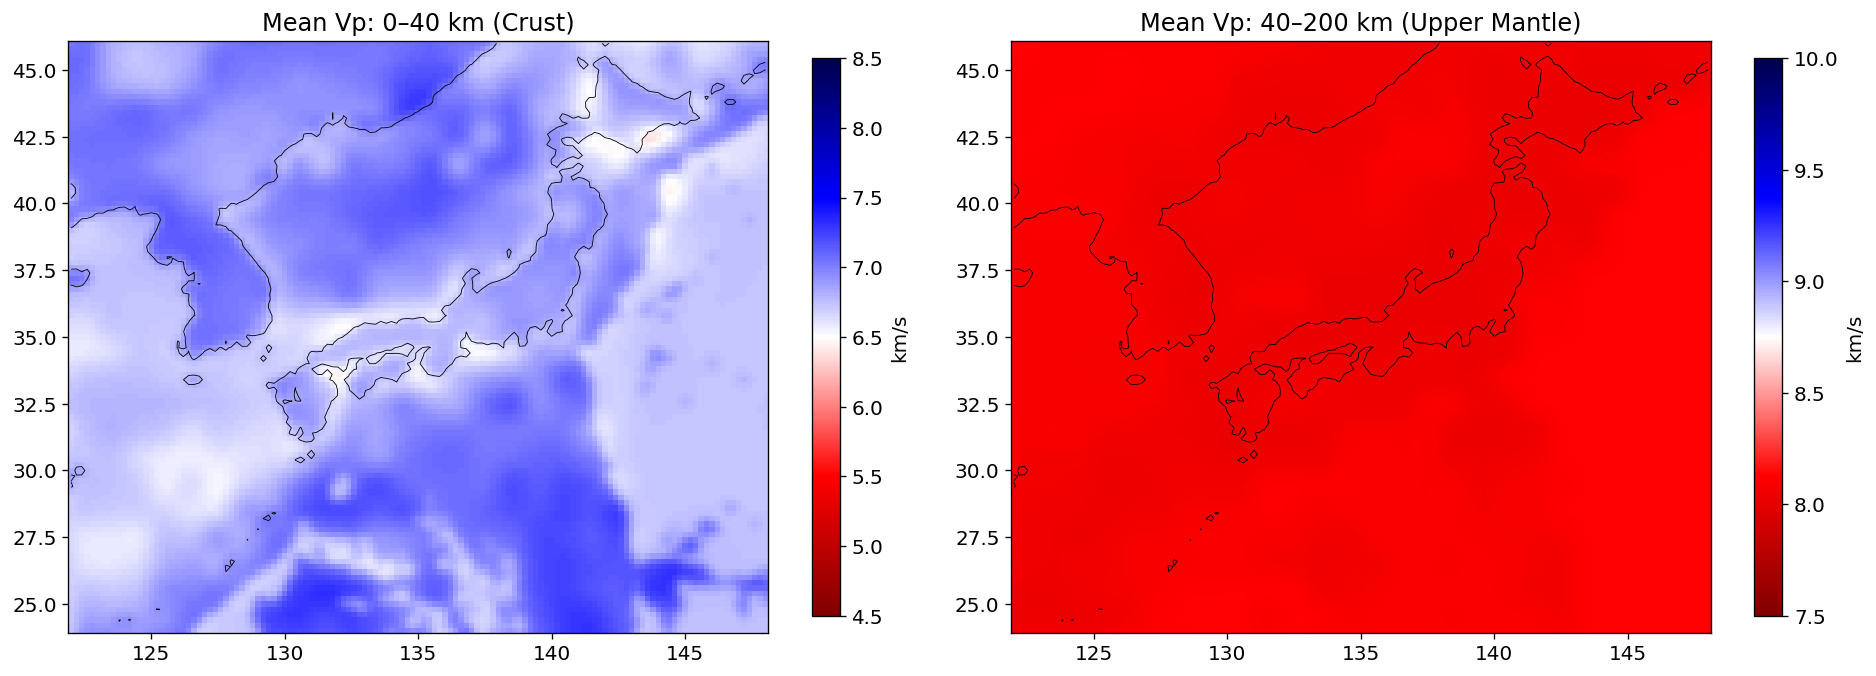

In [13]:
# Average Vp in crust (0–40 km) vs upper mantle (40–200 km)
crust_mask = (depths >= 0) & (depths <= 40)
mantle_mask = (depths > 40) & (depths <= 200)

vp_crust_avg = vel_p[crust_mask, :, :].mean(axis=0)
vp_mantle_avg = vel_p[mantle_mask, :, :].mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

im0 = axes[0].pcolormesh(LON, LAT, vp_crust_avg, cmap="seismic_r",
                          vmin=4.5, vmax=8.5, shading="auto")
axes[0].contour(LON, LAT, topo_km, levels=[0], colors="k", linewidths=0.5)
axes[0].set_title("Mean Vp: 0–40 km (Crust)")
axes[0].set_aspect("equal")
fig.colorbar(im0, ax=axes[0], shrink=0.7, label="km/s")

im1 = axes[1].pcolormesh(LON, LAT, vp_mantle_avg, cmap="seismic_r",
                          vmin=7.5, vmax=10.0, shading="auto")
axes[1].contour(LON, LAT, topo_km, levels=[0], colors="k", linewidths=0.5)
axes[1].set_title("Mean Vp: 40–200 km (Upper Mantle)")
axes[1].set_aspect("equal")
fig.colorbar(im1, ax=axes[1], shrink=0.7, label="km/s")

plt.tight_layout()
plt.show()

## 10. Combined Cross-Section: Vp + Vs Side by Side

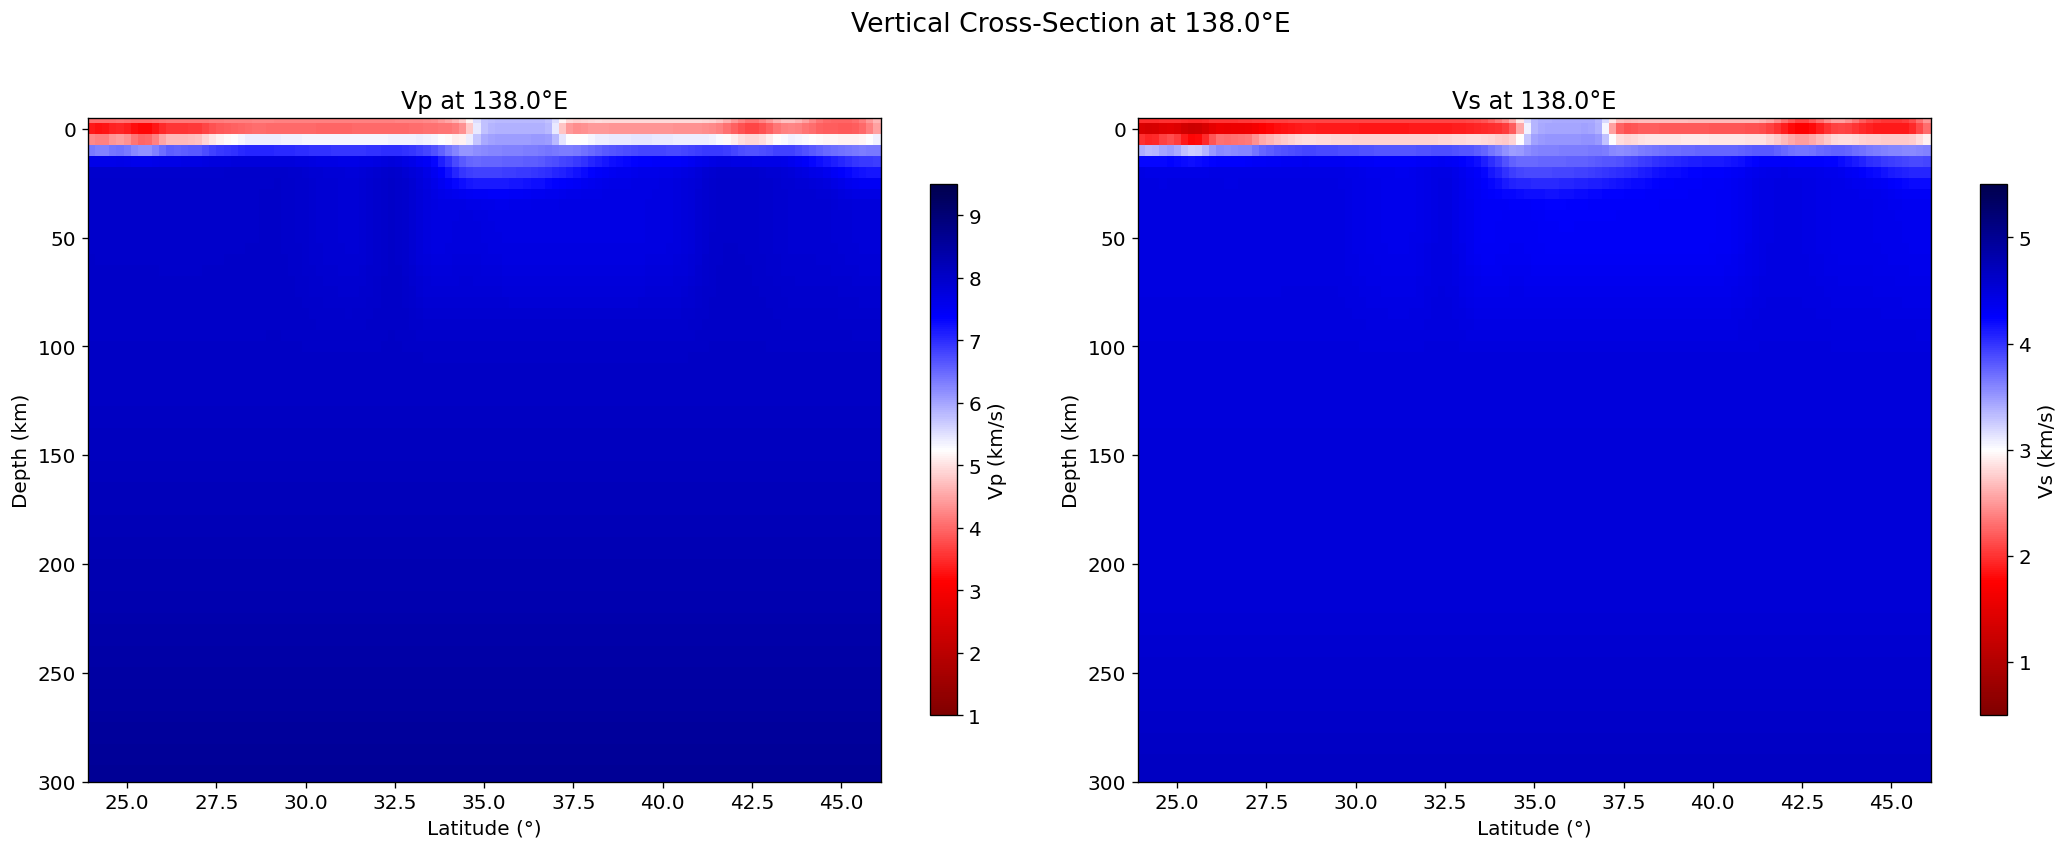

In [14]:
target_lon = 138.0  # Central Honshu
ilon = np.argmin(np.abs(lons - target_lon))
LATS, DEPS = np.meshgrid(lats, depths)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

im0 = axes[0].pcolormesh(LATS, DEPS, vel_p[:, :, ilon], cmap="seismic_r",
                          vmin=1.0, vmax=9.5, shading="auto")
axes[0].set_ylim([300, depths[0]])
axes[0].set_xlabel("Latitude (°)")
axes[0].set_ylabel("Depth (km)")
axes[0].set_title(f"Vp at {lons[ilon]:.1f}°E")
fig.colorbar(im0, ax=axes[0], shrink=0.8, label="Vp (km/s)")

im1 = axes[1].pcolormesh(LATS, DEPS, vel_s[:, :, ilon], cmap="seismic_r",
                          vmin=0.5, vmax=5.5, shading="auto")
axes[1].set_ylim([300, depths[0]])
axes[1].set_xlabel("Latitude (°)")
axes[1].set_ylabel("Depth (km)")
axes[1].set_title(f"Vs at {lons[ilon]:.1f}°E")
fig.colorbar(im1, ax=axes[1], shrink=0.8, label="Vs (km/s)")

fig.suptitle(f"Vertical Cross-Section at {lons[ilon]:.1f}°E", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()